In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# loading dataset

df=pd.read_csv("../Data/train.csv")

In [3]:
# EDA

print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [4]:
df.shape

(9800, 18)

In [5]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')


In [9]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

In [10]:
df.set_index("Order Date", inplace=True)

daily_sales = df["Sales"].resample("D").sum()

print(daily_sales.head())
print(daily_sales.shape)

Order Date
2015-01-03      16.448
2015-01-04     288.060
2015-01-05      19.536
2015-01-06    4407.100
2015-01-07      87.158
Freq: D, Name: Sales, dtype: float64
(1458,)


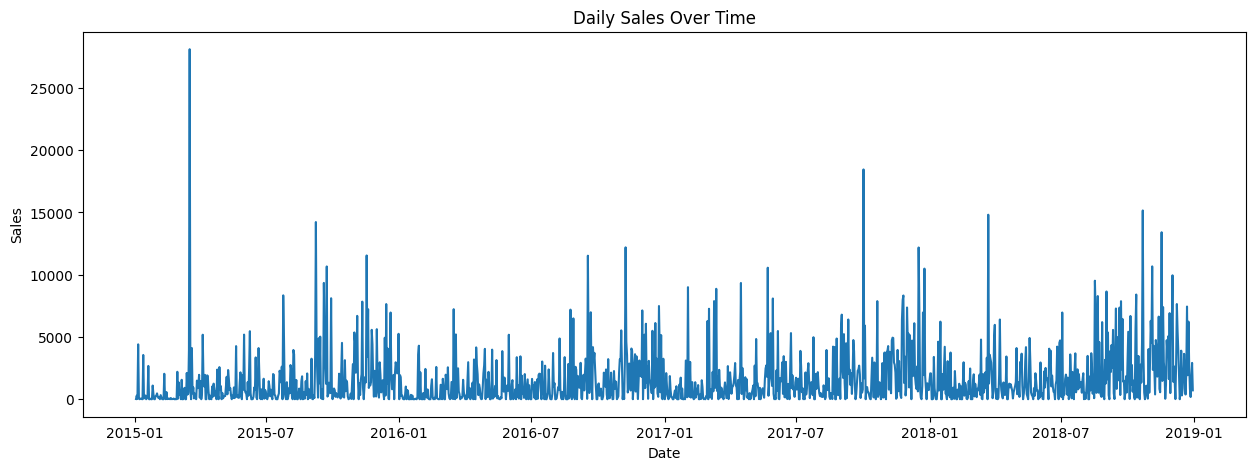

In [11]:

plt.figure(figsize=(15,5))

plt.plot(daily_sales)

plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

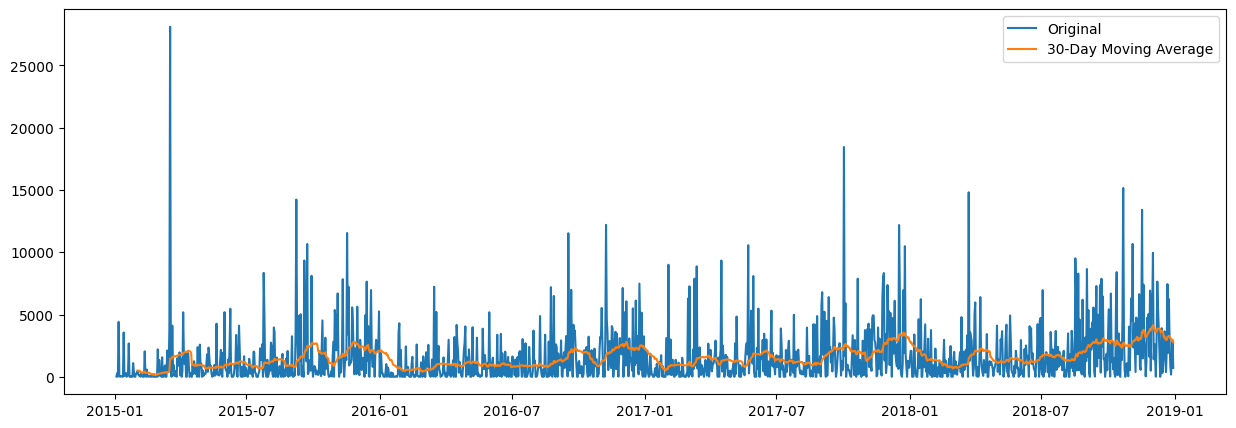

In [12]:
rolling_mean = daily_sales.rolling(window=30).mean()

plt.figure(figsize=(15,5))

plt.plot(daily_sales, label="Original")
plt.plot(rolling_mean, label="30-Day Moving Average")

plt.legend()
plt.show()

In [13]:
monthly_sales = daily_sales.resample("ME").sum()

monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [14]:
yearly_sales = daily_sales.resample("YE").sum()

In [15]:
daily_sales = pd.DataFrame(daily_sales)


# creating features

daily_sales["Lag_1"] = daily_sales["Sales"].shift(1)

In [16]:
daily_sales["Lag_7"] = daily_sales["Sales"].shift(7)

In [17]:
daily_sales["Lag_30"] = daily_sales["Sales"].shift(30)

In [18]:
daily_sales.head(35)

,Sales,Lag_1,Lag_7,Lag_30
Order Date,,,,
2015-01-03,16.448,NaN,NaN,NaN
2015-01-04,288.060,16.448,NaN,NaN
2015-01-05,19.536,288.060,NaN,NaN
2015-01-06,4407.100,19.536,NaN,NaN
2015-01-07,87.158,4407.100,NaN,NaN
2015-01-08,0.000,87.158,NaN,NaN
2015-01-09,40.544,0.000,NaN,NaN
2015-01-10,54.830,40.544,16.448,NaN
2015-01-11,9.940,54.830,288.060,NaN


In [19]:
daily_sales["Day"] = daily_sales.index.day
daily_sales["Month"] = daily_sales.index.month
daily_sales["Year"] = daily_sales.index.year
daily_sales["DayOfWeek"] = daily_sales.index.dayofweek

In [20]:
daily_sales.isnull().sum()

Sales         0
Lag_1         1
Lag_7         7
Lag_30       30
Day           0
Month         0
Year          0
DayOfWeek     0
dtype: int64

In [21]:
daily_sales.dropna(inplace=True)

In [22]:
daily_sales.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1428 entries, 2015-02-02 to 2018-12-30
Freq: D
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Sales      1428 non-null   float64
 1   Lag_1      1428 non-null   float64
 2   Lag_7      1428 non-null   float64
 3   Lag_30     1428 non-null   float64
 4   Day        1428 non-null   int32  
 5   Month      1428 non-null   int32  
 6   Year       1428 non-null   int32  
 7   DayOfWeek  1428 non-null   int32  
dtypes: float64(4), int32(4)
memory usage: 78.1 KB


In [23]:
X = daily_sales.drop("Sales", axis=1)
y = daily_sales["Sales"]

In [24]:
train_size = int(len(daily_sales) * 0.8)

train = daily_sales[:train_size]

test = daily_sales[train_size:]

In [25]:
X_train = train.drop("Sales", axis=1)

y_train = train["Sales"]

X_test = test.drop("Sales", axis=1)

y_test = test["Sales"]

In [26]:
from sklearn.ensemble import RandomForestRegressor

In [27]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [28]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [31]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 1608.2379660769232


In [32]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE:", rmse)

RMSE: 2404.539679719657


In [33]:
print(daily_sales["Sales"].mean())

1573.4328961484593


In [34]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

     Feature  Importance
1      Lag_7    0.241837
0      Lag_1    0.204758
2     Lag_30    0.193530
4      Month    0.141716
3        Day    0.114879
6  DayOfWeek    0.066864
5       Year    0.036417


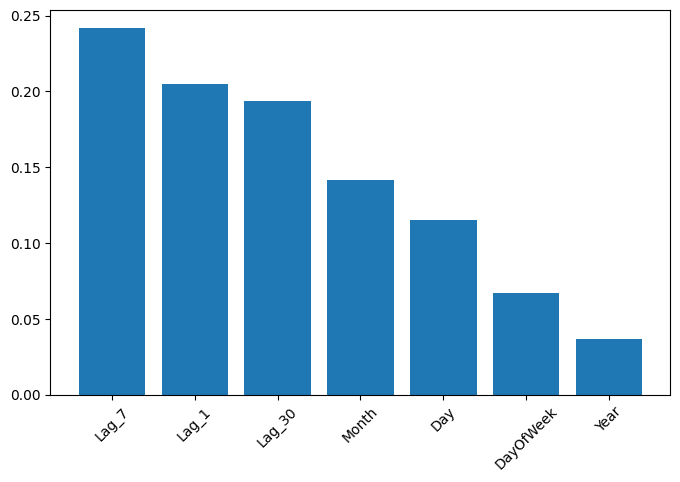

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.show()

In [36]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5]
}
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [37]:
print(grid.best_params_)

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


In [38]:
best_model = grid.best_estimator_

In [39]:
y_pred = best_model.predict(X_test)

In [40]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1587.3328416033244
RMSE: 2415.3638409018886


In [41]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
Order Date,,
2018-03-20,899.568,1288.922895
2018-03-21,3332.636,945.617131
2018-03-22,0.000,477.066596
2018-03-23,14816.068,1210.008541
2018-03-24,1257.298,2230.937176
2018-03-25,3567.026,1260.248141
2018-03-26,3252.880,1294.588247
2018-03-27,2933.516,1399.471188
2018-03-28,1504.702,1316.733389


In [42]:
results["Error"] = (
    results["Actual"]
    - results["Predicted"]
)

results["Absolute_Error"] = (
    results["Error"].abs()
)

results.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute_Error
Order Date,,,,
2018-03-23,14816.0680,1210.008541,13606.059459,13606.059459
2018-10-22,15158.8770,2378.781212,12780.095788,12780.095788
2018-11-17,13408.7928,3801.778356,9607.014444,9607.014444
2018-11-04,10668.0960,2108.789264,8559.306736,8559.306736
2018-08-17,9517.2880,1211.179990,8306.108010,8306.108010
2018-08-21,8284.5340,1325.281327,6959.252673,6959.252673
2018-09-02,8652.3340,1776.217811,6876.116189,6876.116189
2018-09-20,7359.9180,573.365405,6786.552595,6786.552595
2018-10-13,8405.8020,2152.975741,6252.826259,6252.826259


In [43]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)

print("Actual:", y_test.iloc[0])

print("Predicted:", prediction[0])

Actual: 899.568
Predicted: 1288.9228952838725


In [44]:
import joblib

joblib.dump(
    best_model,
    "../sales_forecasting_model.pkl"
)

['../sales_forecasting_model.pkl']